# BDTs to separate the signal from double charm backgrounds

### Setting up the data and tools

In [5]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


### Loading the dataframe with signal and all types of backgrounds

In [8]:
%%time
dfall = load_complete_df()

SegmentationViolation: Template method resolution failed:
  ROOT::RDF::RInterface<ROOT::Detail::RDF::RJittedFilter,void> ROOT::RDF::RInterface<ROOT::Detail::RDF::RLoopManager,void>::Filter(basic_string_view<char,char_traits<char> > expression, basic_string_view<char,char_traits<char> > name = "") =>
    SegmentationViolation: segfault in C++; program state was reset

Error in <TNetXNGFile::Open>: [ERROR] Server responded with an error: [3010] Unable to give access - user access restricted - unauthorized identity used ; Permission denied
 *** Break *** segmentation violation



There was a crash.
This is the entire stack trace of all threads:

Thread 28 (Thread 0x7f2cbaffd640 (LWP 76360) "ZMQbg/IO/0"):
#0  0x00007f2d67325fde in epoll_wait (epfd=62, events=0x7f2cbaffc160, maxevents=256, timeout=-1) at ../sysdeps/unix/sysv/linux/epoll_wait.c:30
#1  0x00007f2d65f2af8a in zmq::epoll_t::loop() () from /opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/zmq/backend/cython/../../../../../libzmq.so.5
#2  0x00007f2d65f5d34f in thread_routine () from /opt/miniconda3/envs/lb-conda-gpu/lib/python3.10/site-packages/zmq/backend/cython/../../../../../libzmq.so.5
#3  0x00007f2d67294b43 in start_thread (arg=<optimized out>) at ./nptl/pthread_create.c:442
#4  0x00007f2d67326a00 in clone3 () at ../sysdeps/unix/sysv/linux/x86_64/clone3.S:81

Thread 27 (Threa

In [4]:
df = dfall.query('eventIndex == 0')

NameError: name 'dfall' is not defined

In [ ]:
mygroupby(df, 'signal')

In [ ]:
mygroupby(dfall.query("eventIndex == 1"), 'signal')

In [ ]:
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.utils import shuffle

# Classifier to separate signal to all other backgrounds

### Data Preparation

In [ ]:
mygroupby(df, 'signal')

### Columns of interest

In [8]:
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]

### Split the dataset in training and test sets

In [9]:
from sklearn.model_selection import train_test_split
df = shuffle(df)
train, test = train_test_split(df, test_size=0.2)

In [10]:
Xtrain = train[train_columns]
ytrain = train["signal"]
Xtest = test[train_columns]
ytest = test["signal"]

In [11]:
Xtrain.shape

(259986, 23)

### Scaling the features for easier training

In [12]:
%%time
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(Xtrain)
Xtrain_scaled = scaler.transform(Xtrain)
Xtest_scaled = scaler.transform(Xtest)

CPU times: user 99.8 ms, sys: 283 µs, total: 100 ms
Wall time: 97.2 ms


In [13]:
type(Xtest)

pandas.core.frame.DataFrame

In [14]:
type(Xtest_scaled)

numpy.ndarray

In [15]:
#plt.hist(Xtest_scaled[:,5], bins=200, range=[-3,3]);

In [16]:
#pd.DataFrame(Xtrain_scaled, columns=Xtrain.columns).describe()

### Training an XGBoost classifier

In [17]:
ratio = len(train[train['signal']==0]) / len(train[train['signal']==1])
print(ratio)

50.71792321464094


In [1]:
model = xgb.XGBClassifier( eval_metric='logloss', 
                          n_estimators=120, eta=0.07, scale_pos_weight=ratio, max_depth=3, random_state=42, tree_method="gpu_hist", verbosity=0)
xgbclass = make_pipeline(scaler, model)
model

NameError: name 'xgb' is not defined

In [39]:
%%time
evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset, verbose=False)

CPU times: user 2.45 s, sys: 16.1 ms, total: 2.47 s
Wall time: 913 ms


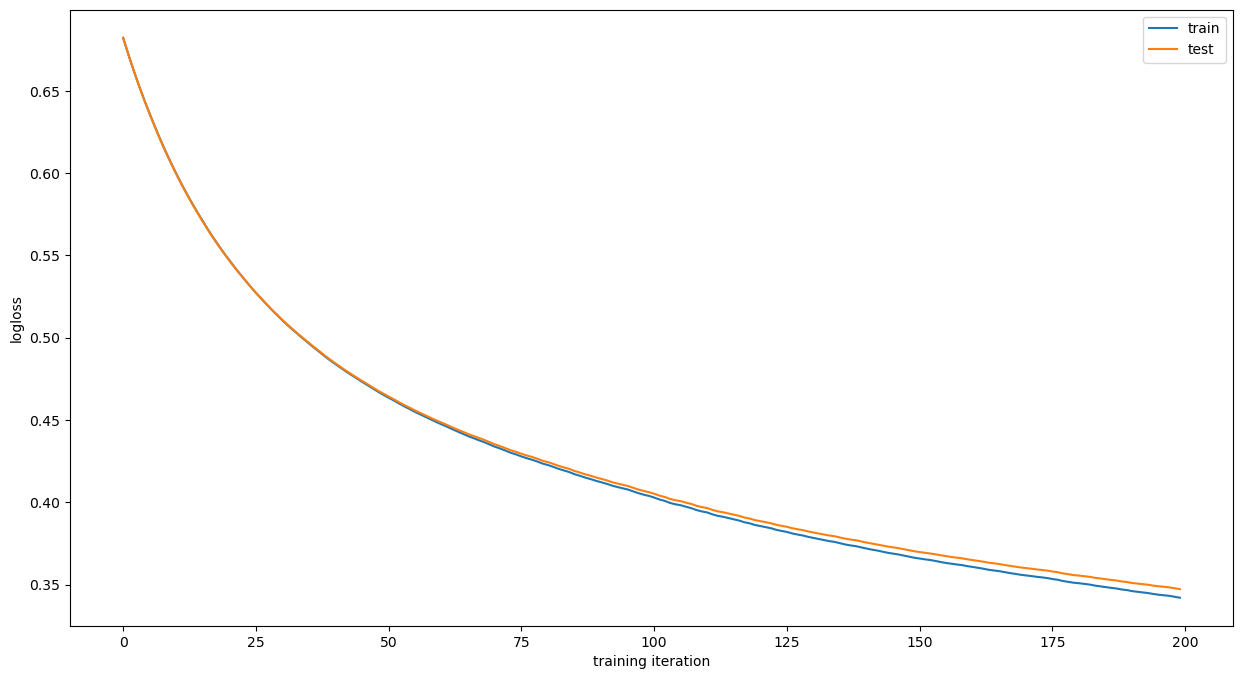

In [40]:
results = model.evals_result()
# plot learning curves
plt.plot(results['validation_0']['logloss'], label='train')
plt.plot(results['validation_1']['logloss'], label='test')
# show the legend
plt.legend()
# show the plot
plt.ylabel("logloss")
plt.xlabel("training iteration")
plt.show()

In [41]:
import joblib
joblib.dump(xgbclass, "bdt_all_42.pkl")

['bdt_all_42.pkl']

### Checking the classifier

In [42]:
yscore = xgbclass.predict_proba(Xtest)
ypred = xgbclass.predict(Xtest)
accuracy = accuracy_score(ytest, ypred)
print('Accuracy: %.3f' % accuracy)

Accuracy: 0.841


0.8947826072922209


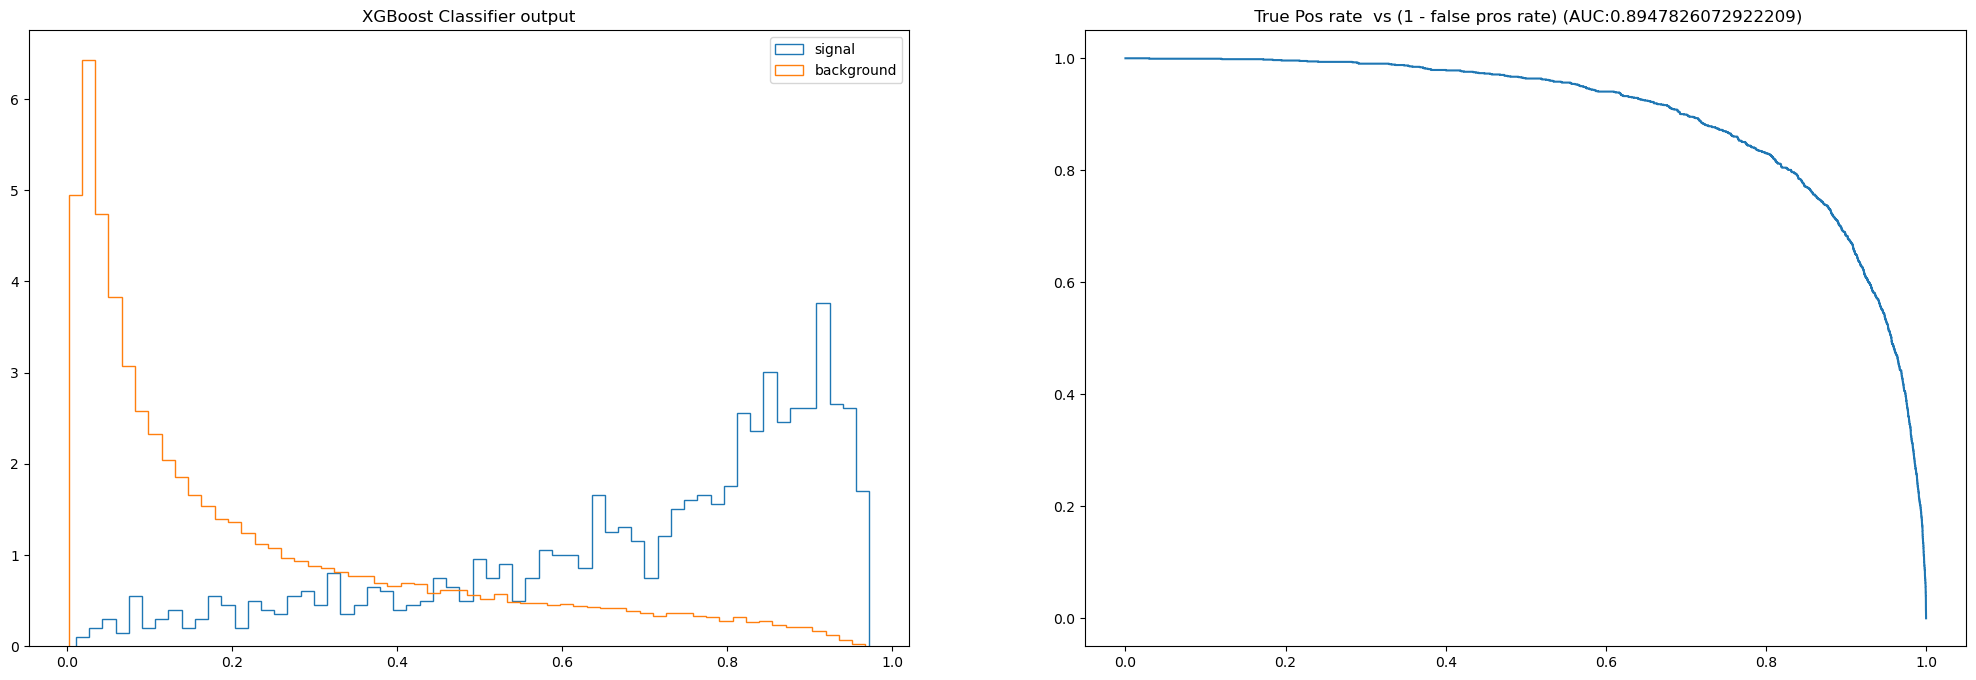

In [43]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = xgbclass.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
ax1.legend();

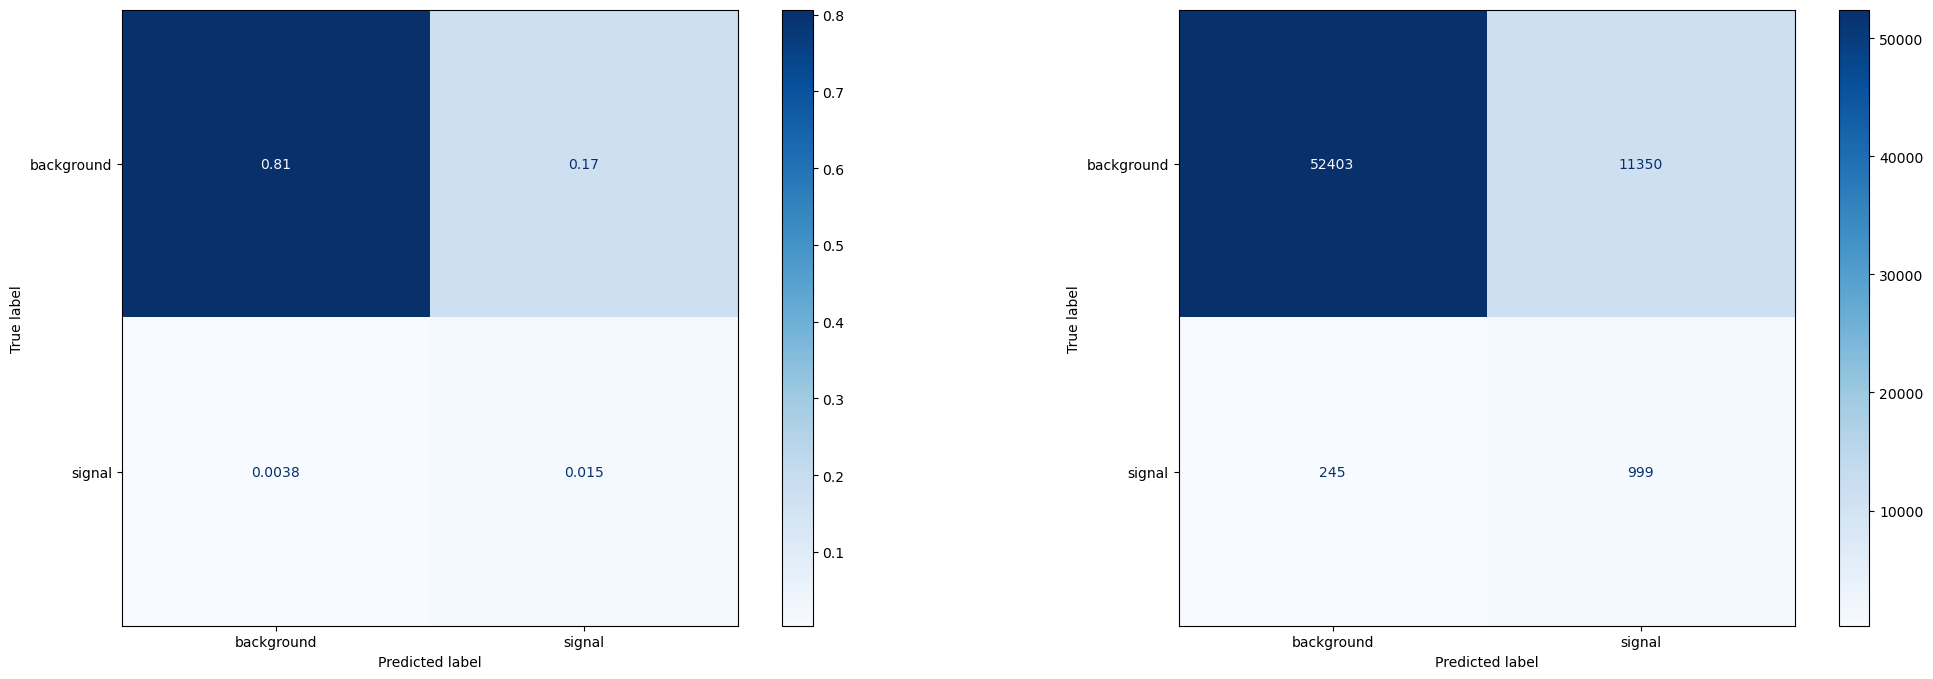

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
confusion_matrix(ytest, ypred)
class_names = [ "background", "signal"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))
ConfusionMatrixDisplay.from_estimator(
        model,
        Xtest_scaled,
        ytest,
        display_labels = class_names,
        cmap=plt.cm.Blues,
        normalize='all',
        ax = ax1
    );
ConfusionMatrixDisplay.from_estimator(
        model,
        Xtest_scaled,
        ytest,
        display_labels = class_names,
        cmap=plt.cm.Blues,
        normalize=None,
        ax = ax2
    );


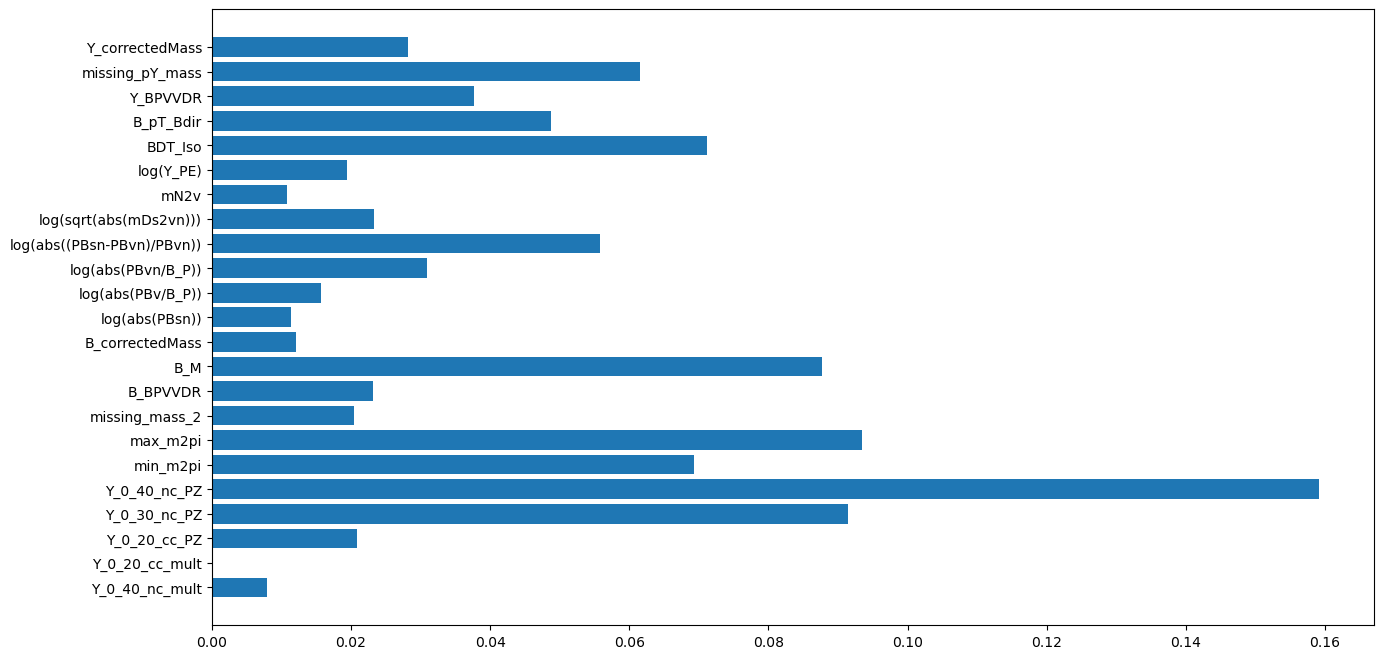

In [25]:
plt.barh(Xtrain.columns, model.feature_importances_);

# Using folds for validation

In [26]:
%%time
from sklearn.model_selection import cross_val_score
cvs = cross_val_score(xgbclass, Xtrain, ytrain, cv=5, scoring='roc_auc')
cvs

CPU times: user 10.3 s, sys: 132 ms, total: 10.4 s
Wall time: 3.59 s


array([0.89149627, 0.89867285, 0.88931078, 0.89890578, 0.89367863])

In [27]:
print(f"Mean   : {np.mean(cvs):.5f}")
print(f"Stddev : {np.std(cvs):.5f}")
#plt.hist(cvs)

Mean   : 0.89441
Stddev : 0.00383


In [28]:
xgbclass.predict_proba(Xtrain[ ytrain > 0.5 ])[:,0]

array([0.65928745, 0.94749665, 0.08812165, ..., 0.45659238, 0.7684352 ,
       0.19026268], dtype=float32)

In [29]:
Xtest[ytest == 1]

,Y_0_40_nc_mult,Y_0_20_cc_mult,Y_0_20_cc_PZ,Y_0_30_nc_PZ,Y_0_40_nc_PZ,min_m2pi,max_m2pi,missing_mass_2,B_BPVVDR,B_M,...,log(abs(PBvn/B_P)),log(abs((PBsn-PBvn)/PBvn)),log(sqrt(abs(mDs2vn))),mN2v,log(Y_PE),BDT_Iso,B_pT_Bdir,Y_BPVVDR,missing_pY_mass,Y_correctedMass
7100,0,0,0.000000,0.000000,0.000000,309.009649,778.365723,-1520.224921,2.844987,3820.299334,...,-0.250171,-4.193841,7.641767,-4.733769e+06,10.454408,0.333239,1551.946672,3.123377,701.163100,1194.198243
2633,0,0,0.000000,0.000000,0.000000,652.552767,1121.056724,-798.499837,2.177950,4312.576260,...,-0.512993,-6.324218,8.075963,-1.114539e+07,12.377230,0.181748,906.963872,3.231152,414.682062,1450.144230
904,0,0,0.000000,0.000000,0.000000,782.839672,1097.899178,-512.569161,2.507101,3888.034208,...,0.531932,-4.230174,7.676548,-3.069993e+06,11.235696,0.323629,1053.482473,3.011501,328.934337,1562.101922
2957,1,0,0.000000,0.000000,2524.636467,707.269518,820.050184,-265.940225,1.679478,3987.576206,...,-0.201294,-8.178688,7.545451,-3.545336e+06,9.932477,0.163810,879.474195,2.071021,372.063751,1403.723218
2277,3,1,5954.971707,1842.856919,9574.955311,548.268790,890.192693,534.043594,2.060180,3794.459909,...,0.271959,-4.406220,7.841883,6.643426e+05,10.481921,0.129313,806.311382,2.246371,342.989083,1612.015115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6762,0,0,0.000000,0.000000,0.000000,552.395056,792.581792,561.985038,1.917284,3902.819366,...,0.104873,-6.834017,7.731149,8.657129e+06,10.864850,0.240570,203.832930,2.534439,549.836968,1399.466886
4954,3,0,0.000000,13789.139813,13789.139813,748.636499,939.470377,768.145865,1.669134,3626.558148,...,0.148784,-2.960958,7.905873,1.542877e+06,10.841403,0.376194,792.810167,1.896374,490.879809,1299.778100
3543,2,0,0.000000,9746.878367,11312.173142,818.163611,821.032407,-984.800703,2.855077,4247.981403,...,-0.114836,-5.347933,7.745920,-3.080972e+06,10.948040,0.420406,1015.228655,3.705143,536.656806,1392.724955
6808,1,1,3384.636182,8129.011805,8129.011805,419.769574,766.286608,-798.615072,3.651765,4678.217182,...,-0.089752,-8.782408,7.775985,-2.379589e+06,11.443555,0.116232,821.262723,4.253185,532.771035,1383.560618


[array([0.34071252, 0.05250336, 0.91187835, ..., 0.5434076 , 0.23156482,
       0.8097373 ], dtype=float32), array([0.13552186, 0.22527368, 0.08284011, ..., 0.5392154 , 0.15815133,
       0.6231324 ], dtype=float32), array([0.9409847 , 0.4554687 , 0.9451863 , ..., 0.8669731 , 0.325739  ,
       0.32816413], dtype=float32), array([0.1019709 , 0.46573296, 0.11192234, ..., 0.6729543 , 0.29349533,
       0.04584239], dtype=float32)]


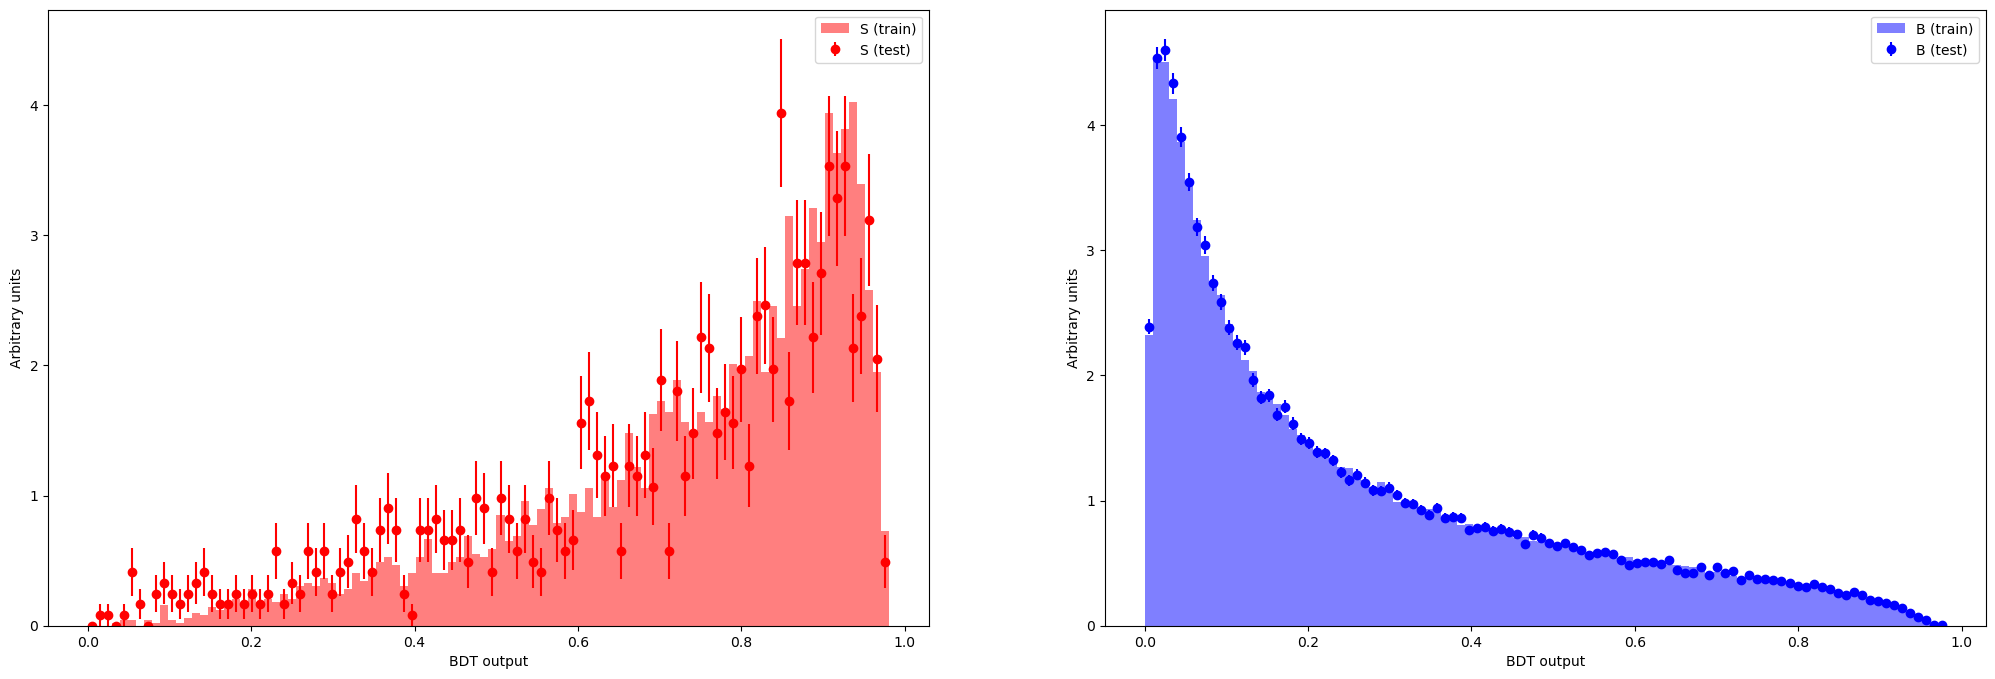

In [30]:
def compare_train_test(clf, X_train, y_train, X_test, y_test, bins=100):
    ''' Taken from Tim Head's recipe: https://betatim.github.io/posts/sklearn-for-TMVA-users/ '''
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))
    decisions = []
    for X,y in ((X_train, y_train), (X_test, y_test)):
        d1 = clf.predict_proba(X[y==1])[:,1]
        d2 = clf.predict_proba(X[y==0])[:,1]
        decisions += [d1, d2]
        
    print(decisions)
        
    low = min(np.min(d) for d in decisions)
    high = max(np.max(d) for d in decisions)
    low_high = (low,high)
    
    ax1.hist(decisions[0],
             color='r', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='S (train)')
    ax2.hist(decisions[1],
             color='b', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='B (train)')

    
    hist, bins = np.histogram(decisions[2],
                              bins=bins, range=low_high, density=True)
    scale = len(decisions[2]) / sum(hist)
    err = np.sqrt(hist * scale) / scale
    
    width = (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    ax1.errorbar(center, hist, yerr=err, fmt='o', c='r', label='S (test)')
    
    hist, bins = np.histogram(decisions[3],
                              bins=bins, range=low_high, density=True)

    scale = len(decisions[3]) / sum(hist)
    
    err = np.sqrt(hist * scale) / scale

    ax2.errorbar(center, hist, yerr=err, fmt='o', c='b', label='B (test)')

    ax1.set_xlabel("BDT output")
    ax1.set_ylabel("Arbitrary units")
    ax1.legend(loc='best')

    ax2.set_xlabel("BDT output")
    ax2.set_ylabel("Arbitrary units")
    ax2.legend(loc='best')

    
compare_train_test(xgbclass, Xtrain, ytrain, Xtest, ytest)


# Optimizer for Optuna using the scikit learn interface

In [31]:
import optuna
import xgboost as xgb
import sklearn

In [36]:
def objective(trial):
    model = xgb.XGBClassifier(eval_metric='logloss', 
                              n_estimators=trial.suggest_int("n_estimators", 100, 600), 
                              eta=trial.suggest_float("eta", 1e-8, 1), # 0.03, 
                              scale_pos_weight=ratio, 
                              max_depth=trial.suggest_int("max_depth", 1, 9), #4
                              random_state=42, 
                              tree_method="gpu_hist",
                             verbosity=0)
    evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
    res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset, verbose=False)
    yscore = xgbclass.predict_proba(Xtest)
    fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
    roc_auc = auc(fpr, tpr)
    return roc_auc

In [37]:

study_name = "sklearn_bdt"
study = optuna.create_study(direction="maximize", study_name="sklearn_bdt", storage="sqlite:///{}.db".format("sklearn_BDT"), load_if_exists=True)
study.optimize(objective, n_trials=100)
print(study.best_trial)

[I 2023-09-08 11:45:25,237] Using an existing study with name 'sklearn_bdt' instead of creating a new one.
[I 2023-09-08 11:45:26,975] Trial 255 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 551, 'eta': 0.3997761319797681, 'max_depth': 5}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:45:29,989] Trial 256 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 513, 'eta': 0.14877225800085936, 'max_depth': 8}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:45:31,300] Trial 257 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 293, 'eta': 0.9805075326700059, 'max_depth': 6}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:45:33,020] Trial 258 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 590, 'eta': 0.23017390021509035, 'max_depth': 5}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:45:34,398] Trial 259 finished with val

[I 2023-09-08 11:46:29,929] Trial 294 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 362, 'eta': 0.24492204201324197, 'max_depth': 2}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:46:32,589] Trial 295 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 594, 'eta': 0.08191992585990289, 'max_depth': 7}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:46:34,004] Trial 296 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 449, 'eta': 0.33711107401683443, 'max_depth': 5}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:46:37,474] Trial 297 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 470, 'eta': 0.29045061723418397, 'max_depth': 9}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:46:39,202] Trial 298 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 569, 'eta': 0.9249708493276145, 'max_depth': 5}. 

[I 2023-09-08 11:47:38,642] Trial 334 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 308, 'eta': 0.25838313316258116, 'max_depth': 8}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:47:40,112] Trial 335 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 590, 'eta': 0.3542106028104306, 'max_depth': 4}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:47:41,057] Trial 336 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 550, 'eta': 0.7864625215840814, 'max_depth': 1}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:47:42,541] Trial 337 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 456, 'eta': 0.8944374380101896, 'max_depth': 5}. Best is trial 12 with value: 0.8999792065732434.
[I 2023-09-08 11:47:43,919] Trial 338 finished with value: 0.8954227322661016 and parameters: {'n_estimators': 427, 'eta': 0.32439315707221694, 'max_depth': 5}. Be

FrozenTrial(number=12, state=TrialState.COMPLETE, values=[0.8999792065732434], datetime_start=datetime.datetime(2023, 9, 8, 11, 31, 21, 661029), datetime_complete=datetime.datetime(2023, 9, 8, 11, 31, 23, 771266), params={'n_estimators': 553, 'eta': 0.26160414235002805, 'max_depth': 5}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=600, log=False, low=100, step=1), 'eta': FloatDistribution(high=1.0, log=False, low=1e-08, step=None), 'max_depth': IntDistribution(high=9, log=False, low=1, step=1)}, trial_id=13, value=None)


# Optimizing the search parameters with Optuna

In [ ]:
np.savez("bdt_training_data", Xtrain_scaled=Xtrain_scaled, ytrain=ytrain, Xtest_scaled=Xtest_scaled, ytest=ytest)

In [ ]:
data = np.load("bdt_training_data.npz")
xtr = data['Xtrain_scaled']
ytr = data['ytrain']
xte = data['Xtest_scaled']
xte = data['ytest']


In [ ]:
np.count_nonzero(ytr)

In [ ]:
ytr.shape

In [ ]:
np.count_nonzero(ytr == 0)

In [ ]:
np.count_nonzero(ytr == 0) / np.count_nonzero(ytr)

In [ ]:
import optuna
import xgboost as xgb
import sklearn

In [ ]:
# model = xgb.XGBClassifier( eval_metric='logloss', 
#                           n_estimators=300, eta=0.03, scale_pos_weight=ratio, max_depth=4, random_state=42, tree_method="gpu_hist")
# xgbclass = make_pipeline(scaler, model)

dtrain = xgb.DMatrix(Xtrain_scaled, label=ytrain)
dvalid = xgb.DMatrix(Xtest_scaled, label=ytest)
    
#     parameters = {
#     'learning_rate': [0.1, 0.05],#, 0.05],
#     'max_depth': range (2, 5, 1),
#     'n_estimators': [ 60, 200,],# 500, 1000 ],
#     'num_boost_round': [60, 250]#, 500, 1000]  
    
param = {
    "eval_metric": "logloss",
    "verbosity": 2,
    #"objective": "binary:logistic",
    "booster": "gbtree",
    "eta":0.03,
    "scale_pos_weight": ratio,
    "max_depth":4,
    "random_state": 42,
    "tree_method": "gpu_hist",
}

bst = xgb.train(param, dtrain, num_boost_round=300)
yscore = bst.predict(dvalid)
fpr, tpr, _ = roc_curve(ytest, yscore)
roc_auc = auc(fpr, tpr)
print(f"AUC:{roc_auc}")

In [ ]:
#evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
#res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset)

def objective(trial):

    dtrain = xgb.DMatrix(Xtrain_scaled, label=ytrain)
    dvalid = xgb.DMatrix(Xtest_scaled, label=ytest)
    
#     parameters = {
#     'learning_rate': [0.1, 0.05],#, 0.05],
#     'max_depth': range (2, 5, 1),
#     'n_estimators': [ 60, 200,],# 500, 1000 ],
#     'num_boost_round': [60, 250]#, 500, 1000]  
    
    param = {
        "verbosity": 0,
        "objective": "binary:logistic",
        # defines booster, gblinear for linear functions.
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        # L2 regularization weight.
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        # L1 regularization weight.
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        # sampling ratio for training data.
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        # sampling according to each tree.
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "tree_method": "gpu_hist",
    }

    if param["booster"] in ["gbtree", "dart"]:
        # maximum depth of the tree, signifies complexity of the tree.
        param["max_depth"] = trial.suggest_int("max_depth", 1, 9, step=2)
        # minimum child weight, larger the term more conservative the tree.
        param["min_child_weight"] = trial.suggest_int("min_child_weight", 2, 10)
        param["eta"] = trial.suggest_float("eta", 1e-8, 1.0, log=True)
        # defines how selective algorithm is.
        param["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0, log=True)
        param["grow_policy"] = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    if param["booster"] == "dart":
        param["sample_type"] = trial.suggest_categorical("sample_type", ["uniform", "weighted"])
        param["normalize_type"] = trial.suggest_categorical("normalize_type", ["tree", "forest"])
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-8, 1.0, log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-8, 1.0, log=True)

    bst = xgb.train(param, dtrain, num_boost_round= trial.suggest_int("num_boost_round", 100, 800))
    yscore = bst.predict(dvalid)
    fpr, tpr, _ = roc_curve(ytest, yscore)
    roc_auc = auc(fpr, tpr)
    print(f"AUC:{roc_auc}")
    return roc_auc

#     preds = bst.predict(dvalid)
#     pred_labels = np.rint(preds)
#     accuracy = sklearn.metrics.accuracy_score(ytest, pred_labels)
#     return accuracy


In [ ]:
study = optuna.create_study(direction="maximize", study_name="bdt", storage="sqlite:///{}.db".format("BDT"), load_if_exists=True)
study.optimize(objective, n_trials=100)
print(study.best_trial)

# Optimizing the parameters with GridSearchCV

In [ ]:
parameters = {
    'learning_rate': [0.1, 0.05],#, 0.05],
    'max_depth': range (2, 5, 1),
    'n_estimators': [ 60, 200,],# 500, 1000 ],
    'num_boost_round': [60, 250]#, 500, 1000]  
}

c.f. https://neptune.ai/blog/xgboost-everything-you-need-to-know

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=model,
    param_grid=parameters,
    scoring = 'roc_auc',
    n_jobs = 8,
    cv = 2,
    verbose=10
)

In [ ]:
grid_search.fit(Xtrain_scaled, ytrain)

In [ ]:
xg_best = grid_search.best_estimator_
xg_best

In [ ]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = xg_best.predict_proba(Xtest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
ax1.legend();

In [ ]:
plt.barh(Xtrain.columns, model.feature_importances_);